In [1]:
# all imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import os
import json
import re
from scipy import stats
import pickle

In [2]:
# open results.pkl
with open("results.pkl", "rb") as f:
    results = pickle.load(f)

In [4]:
results.keys()

dict_keys(['pop_response', 'pop_response_video', 'pop_response_behavior', 'pop_response_video_behavior', 'n_pop_neurons_zero'])

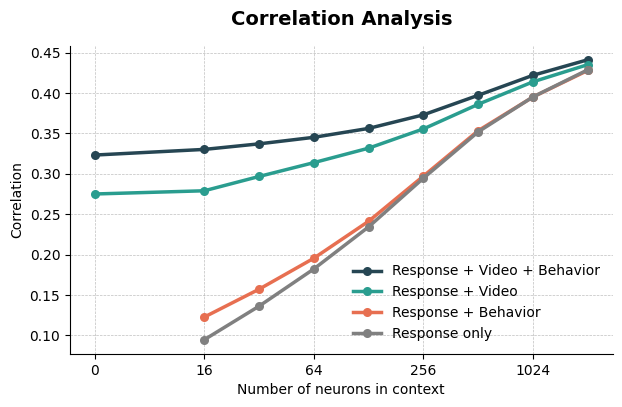

In [5]:
# unpack results into plotting variables
n_pop_neurons = results["n_pop_neurons_zero"][1:]
n_pop_neurons_zero = results["n_pop_neurons_zero"]
pop_response = results["pop_response"]
pop_response_video = results["pop_response_video"]
pop_response_behavior = results["pop_response_behavior"]
pop_response_video_behavior = results["pop_response_video_behavior"]

c = { 
    "base": "gray",  # Light Grey (Response Only)
    "vid":  "#2A9D8F",  # Deep Teal  (Video)
    "beh":  "#E76F51",  # Burnt Sienna (Behavior)
    "both": "#264653"   # Charcoal (Both)
}

# ==========================================
# 3. PLOTTING
# ==========================================
fig, axs = plt.subplots(1, 1, figsize=(7, 4))

# --- LEFT SUBPLOT: The 4 Conditions ---
ax_left = ax = axs

# Helper for slick markers
kwargs = {'lw': 2.5, 'markersize': 5, 'markeredgecolor': 'white', 'markeredgewidth': 1.5}
kwargs = {'lw': 2.5, 'markersize': 5,  'markeredgewidth': 1.5}


ax_left.semilogx(n_pop_neurons_zero, pop_response_video_behavior, 'o-', 
                 label="Response + Video + Behavior", color=c["both"], **kwargs)

ax_left.semilogx(n_pop_neurons_zero, pop_response_video, 'o-', 
                 label="Response + Video", color=c["vid"], **kwargs)
ax_left.semilogx(n_pop_neurons, pop_response_behavior, 'o-', 
                 label="Response + Behavior", color=c["beh"], **kwargs)
ax_left.semilogx(n_pop_neurons, pop_response, 'o-', 
                 label="Response only", color=c["base"], **kwargs)

ax_left.set_title("Correlation Analysis", fontsize=14, fontweight='bold', pad=15)
ax_left.set_ylabel("Correlation")


# ==========================================
# 4. SHARED STYLING
# ==========================================
# Custom X Ticks
ax.set_xticks([4, 16, 64, 256, 1024])
ax.set_xticklabels([0, 16, 64, 256, 1024])
ax.minorticks_off()  # Remove minor ticks

# Grid and Spines
ax.grid(True, linestyle='--', alpha=0.5, color='gray', linewidth=0.5)
ax.set_xlabel("Number of neurons in context")

# Clean spines (Despine)
sns.despine(ax=ax)

# Legend (Frameon=False for cleaner look)
ax.legend(frameon=False, fontsize=10, )

#plt.tight_layout()
plt.savefig("insilico.svg", dpi=300, bbox_inches="tight")